In [1]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve, ConfusionMatrixDisplay
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

sns.set_theme(style='whitegrid', palette='muted')
print('Libraries loaded')

Libraries loaded


In [2]:
athletes_df = pd.read_csv('athlete_events.csv')
medals_country_df = pd.read_csv('Olympics (1896-2024).csv')
noc_region_df = pd.read_csv('noc_regions.csv')


In [3]:
print('Athletes dataset shape:', athletes_df.shape)
print('Country medals dataset shape:', medals_country_df.shape)


Athletes dataset shape: (271116, 15)
Country medals dataset shape: (1436, 7)


In [4]:
merged_df = athletes_df.merge(medals_country_df, on='NOC', how='left')

print('Merged dataset shape:', merged_df.shape)
merged_df.head()

Merged dataset shape: (271116, 21)


,ID,Name,Sex,Age,Height,Weight,Team,NOC,Games,Year_x,...,City,Sport,Event,Medal,Year_y,Rank,Gold,Silver,Bronze,Total
0,1,A Dijiang,M,24.0,180.0,80.0,China,CHN,1992 Summer,1992,...,Barcelona,Basketball,Basketball Men's Basketball,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,A Lamusi,M,23.0,170.0,60.0,China,CHN,2012 Summer,2012,...,London,Judo,Judo Men's Extra-Lightweight,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,3,Gunnar Nielsen Aaby,M,24.0,NaN,NaN,Denmark,DEN,1920 Summer,1920,...,Antwerpen,Football,Football Men's Football,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,4,Edgar Lindenau Aabye,M,34.0,NaN,NaN,Denmark/Sweden,DEN,1900 Summer,1900,...,Paris,Tug-Of-War,Tug-Of-War Men's Tug-Of-War,Gold,NaN,NaN,NaN,NaN,NaN,NaN
4,5,Christine Jacoba Aaftink,F,21.0,185.0,82.0,Netherlands,NED,1988 Winter,1988,...,Calgary,Speed Skating,Speed Skating Women's 500 metres,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [5]:
swimming_df = merged_df[
    (merged_df['Sport'] == 'Swimming') &
    (merged_df['Year_x'] >= 1968)
].copy()
print('Swimming dataset shape:', swimming_df.shape)
swimming_df['Medal'] = swimming_df['Medal'].fillna('None')
print('Medal distribution in swimming dataset:')
print(swimming_df['Medal'].value_counts())


Swimming dataset shape: (18641, 21)
Medal distribution in swimming dataset:
Medal
None      16437
Gold        795
Silver      716
Bronze      693
Name: count, dtype: int64


In [6]:
#See all unique swimming events 
print(swimming_df['Event'].unique())
print('\nTotal unique events:', swimming_df['Event'].nunique())

["Swimming Men's 100 metres Butterfly"
 "Swimming Men's 200 metres Butterfly"
 "Swimming Men's 4 x 100 metres Medley Relay"
 "Swimming Men's 100 metres Freestyle"
 "Swimming Men's 50 metres Freestyle"
 "Swimming Women's 100 metres Backstroke"
 "Swimming Women's 200 metres Backstroke"
 "Swimming Women's 4 x 100 metres Medley Relay"
 "Swimming Women's 50 metres Freestyle"
 "Swimming Men's 400 metres Freestyle"
 "Swimming Men's 200 metres Freestyle"
 "Swimming Men's 4 x 100 metres Freestyle Relay"
 "Swimming Men's 4 x 200 metres Freestyle Relay"
 "Swimming Men's 100 metres Backstroke"
 "Swimming Men's 200 metres Backstroke"
 "Swimming Men's 200 metres Individual Medley"
 "Swimming Men's 400 metres Individual Medley"
 "Swimming Women's 4 x 100 metres Freestyle Relay"
 "Swimming Men's 200 metres Breaststroke"
 "Swimming Men's 1,500 metres Freestyle"
 "Swimming Women's 200 metres Butterfly"
 "Swimming Women's 400 metres Individual Medley"
 "Swimming Women's 200 metres Freestyle"
 "Swimming W

In [7]:
freestyle_events = [e for e in swimming_df['Event'].unique() 
                    if 'Freestyle' in e and 'Relay' not in e]

butterfly_events = [e for e in swimming_df['Event'].unique() 
                    if 'Butterfly' in e and 'Relay' not in e]

print('Freestyle events:')
for e in freestyle_events:
    print(' -', e)

print('\nButterfly events:')
for e in butterfly_events:
    print(' -', e)



Freestyle events:
 - Swimming Men's 100 metres Freestyle
 - Swimming Men's 50 metres Freestyle
 - Swimming Women's 50 metres Freestyle
 - Swimming Men's 400 metres Freestyle
 - Swimming Men's 200 metres Freestyle
 - Swimming Men's 1,500 metres Freestyle
 - Swimming Women's 200 metres Freestyle
 - Swimming Women's 400 metres Freestyle
 - Swimming Women's 800 metres Freestyle
 - Swimming Women's 100 metres Freestyle

Butterfly events:
 - Swimming Men's 100 metres Butterfly
 - Swimming Men's 200 metres Butterfly
 - Swimming Women's 200 metres Butterfly
 - Swimming Women's 100 metres Butterfly


In [8]:
freestyle_df = swimming_df[swimming_df['Event'].isin(freestyle_events)].copy()
butterfly_df = swimming_df[swimming_df['Event'].isin(butterfly_events)].copy()

print('Freestyle rows:', freestyle_df.shape[0])
print('Butterfly rows:', butterfly_df.shape[0])

Freestyle rows: 5469
Butterfly rows: 2038


In [9]:
country_strength = medals_country_df.groupby('NOC')['Total'].sum().reset_index()
country_strength.columns = ['NOC', 'Country_Strength']

In [10]:
def preprocess(df,country_strength):
    df = df.copy()
    
    df['Age'] = df['Age'].fillna(df['Age'].median())
    df['Height'] = df['Height'].fillna(df['Height'].median())
    df['Weight'] = df['Weight'].fillna(df['Weight'].median())
  
    df['Medal_Won'] = (df['Medal'] != 'None').astype(int)
    

    df = df.sort_values(['ID', 'Year_x']).reset_index(drop=True)
    
    df['Previous_Appearances'] = df.groupby('ID').cumcount()
    df['Cumulative_Medals_Before'] = (
        df.groupby('ID')['Medal_Won']
        .cumsum()
        .shift(fill_value=0)
    )
    df['Previous_Medal'] = (df['Cumulative_Medals_Before'] > 0).astype(int)
  
    df = df[df['Previous_Appearances'] > 0].copy()
  
    le = LabelEncoder()
    df['Sex_enc'] = le.fit_transform(df['Sex'])
    df['Event_enc'] = le.fit_transform(df['Event'])
    df = df.merge(country_strength, on='NOC', how='left')
    df['Country_Strength'] = df['Country_Strength'].fillna(0)

    return df

freestyle_df = preprocess(freestyle_df, country_strength)
butterfly_df = preprocess(butterfly_df, country_strength)

print('Freestyle rows after preprocessing:', freestyle_df.shape[0])
print('Butterfly rows after preprocessing:', butterfly_df.shape[0])

Freestyle rows after preprocessing: 2693
Butterfly rows after preprocessing: 827


In [ ]:
def run_models(df, group_name):
    print(f' {group_name}')
    
    Features = [
        'Age', 'Height', 'Weight',
        'Sex_enc', 'Event_enc','Country_Strength', 'NOC_enc',
        'Previous_Appearances',
        'Cumulative_Medals_Before',
        'Previous_Medal'
    ]
    
    X = df[Features]
    y = df['Medal_Won']
    
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )
    
    models = {
        'Random Forest': RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42),
        'Gradient Boosting': GradientBoostingClassifier(n_estimators=100, random_state=42)
    }
    
    for name, m in models.items():
        m.fit(X_train, y_train)
        y_pred = m.predict(X_test)
        y_proba = m.predict_proba(X_test)[:, 1]
        auc = roc_auc_score(y_test, y_proba)
        print(f'\n {name} ')
        print(classification_report(y_test, y_pred, target_names=['No Medal', 'Medal']))
        print(f'AUC Score: {auc:.4f}')
    
    return models, X_test, y_test

def preprocess(df, country_strength):
    df = df.copy()
    
    df['Age'] = df['Age'].fillna(df['Age'].median())
    df['Height'] = df['Height'].fillna(df['Height'].median())
    df['Weight'] = df['Weight'].fillna(df['Weight'].median())

    df['Medal_Won'] = (df['Medal'] != 'None').astype(int)

    df = df.sort_values(['ID', 'Year_x']).reset_index(drop=True)

    df['Previous_Appearances'] = df.groupby('ID').cumcount()
    df['Cumulative_Medals_Before'] = (
        df.groupby('ID')['Medal_Won']
        .cumsum()
        .shift(fill_value=0)
    )
    df['Previous_Medal'] = (df['Cumulative_Medals_Before'] > 0).astype(int)

    df = df[df['Previous_Appearances'] > 0].copy()

    df['Sex_enc'] = LabelEncoder().fit_transform(df['Sex'])
    df['Event_enc'] = LabelEncoder().fit_transform(df['Event'])
    df['NOC_enc'] = LabelEncoder().fit_transform(df['NOC'])

    df = df.merge(country_strength, on='NOC', how='left')
    df['Country_Strength'] = df['Country_Strength'].fillna(0)

    return df
butterfly_models, butterfly_X_test, butterfly_y_test = run_models(butterfly_df, 'BUTTERFLY')

 FREESTYLE


KeyError: "['NOC_enc'] not in index"

In [ ]:
# ── Print AUC scores clearly ─────────────────────────────────────
for name, m in freestyle_models.items():
    y_proba = m.predict_proba(freestyle_X_test)[:, 1]
    auc = roc_auc_score(freestyle_y_test, y_proba)
    print(f'Freestyle {name} AUC: {auc:.4f}')

for name, m in butterfly_models.items():
    y_proba = m.predict_proba(butterfly_X_test)[:, 1]
    auc = roc_auc_score(butterfly_y_test, y_proba)
    print(f'Butterfly {name} AUC: {auc:.4f}')

Freestyle Random Forest AUC: 0.8539
Freestyle Gradient Boosting AUC: 0.8617
Butterfly Random Forest AUC: 0.7910
Butterfly Gradient Boosting AUC: 0.7635


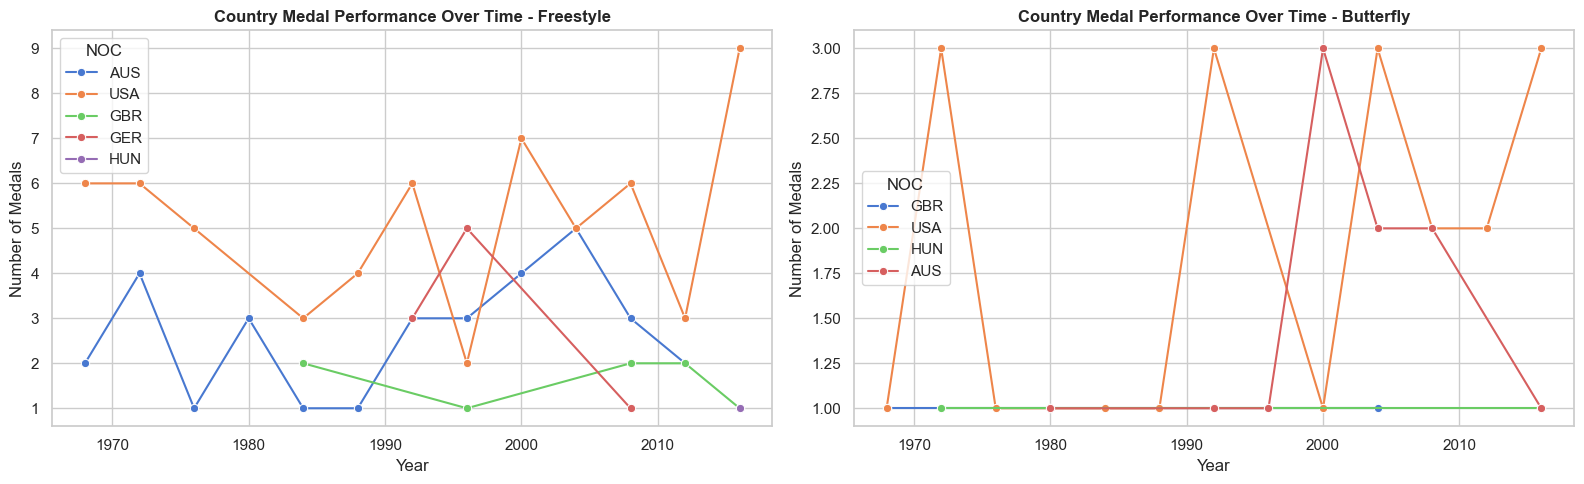

In [ ]:
top_countries = ['USA', 'AUS', 'GBR', 'GER', 'HUN']

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

for ax, (df, title) in zip(axes, [
    (freestyle_df, 'Freestyle'),
    (butterfly_df, 'Butterfly')
]):
    country_time = df[
        (df['NOC'].isin(top_countries)) &
        (df['Medal_Won'] == 1)
    ].groupby(['Year_x', 'NOC']).size().reset_index(name='Medal_Count')
    
    sns.lineplot(data=country_time, x='Year_x', y='Medal_Count',
                 hue='NOC', marker='o', ax=ax)
    ax.set_title(f'Country Medal Performance Over Time - {title}',
                 fontsize=12, fontweight='bold')
    ax.set_xlabel('Year')
    ax.set_ylabel('Number of Medals')

plt.tight_layout()
plt.show()

In [ ]:
# Medal probability by country strength tier
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, (df, title) in zip(axes, [
    (freestyle_df, 'Freestyle'),
    (butterfly_df, 'Butterfly')
]):
    df = df.copy()
    df['Strength_Tier'] = pd.qcut(df['Country_Strength'], q=4,
                                   labels=['Low', 'Medium', 'High', 'Elite'])
    
    medal_rate = df.groupby('Strength_Tier')['Medal_Won'].mean().reset_index()
    medal_rate['Medal_Rate_%'] = medal_rate['Medal_Won'] * 100
    
    sns.barplot(data=medal_rate, x='Strength_Tier', y='Medal_Rate_%',
                palette='Blues_d', ax=ax)
    ax.set_title(f'Medal Rate by Country Strength Tier - {title}',
                 fontsize=12, fontweight='bold')
    ax.set_xlabel('Country Strength Tier')
    ax.set_ylabel('Medal Win Rate (%)')

plt.tight_layout()
plt.show()

In [ ]:
print('Freestyle with new features:')
print(freestyle_df[['Name', 'Year_x', 'Event', 'Age', 
                     'Previous_Appearances', 
                     'Cumulative_Medals_Before',
                     'Previous_Medal', 
                     'Medal_Won']].head(10).to_string())

print('\nButterfly with new features:')
print(butterfly_df[['Name', 'Year_x', 'Event', 'Age', 
                     'Previous_Appearances', 
                     'Cumulative_Medals_Before',
                     'Previous_Medal', 
                     'Medal_Won']].head(10).to_string())

Freestyle with new features:
                             Name  Year_x                                  Event   Age  Previous_Appearances  Cumulative_Medals_Before  Previous_Medal  Medal_Won
7         Roosevelt M. Abdulgafur    1968    Swimming Men's 200 metres Freestyle  24.0                     1                         0               0          0
15             Rui Pinto de Abreu    1980    Swimming Men's 100 metres Freestyle  19.0                     1                         0               0          0
16             Rui Pinto de Abreu    1980    Swimming Men's 200 metres Freestyle  19.0                     2                         0               0          0
20  Marcelo Alberto Acosta Jimnez    2016    Swimming Men's 400 metres Freestyle  20.0                     1                         0               0          0
21  Marcelo Alberto Acosta Jimnez    2016  Swimming Men's 1,500 metres Freestyle  20.0                     2                         0               0          0

In [ ]:
print('FREESTYLE Medal Distribution:')
print(freestyle_df['Medal_Won'].value_counts())
print(f'Medal rate: {freestyle_df["Medal_Won"].mean()*100:.1f}%')

print('\nBUTTERFLY Medal Distribution:')
print(butterfly_df['Medal_Won'].value_counts())
print(f'Medal rate: {butterfly_df["Medal_Won"].mean()*100:.1f}%')

FREESTYLE Medal Distribution:
Medal_Won
0    2464
1     229
Name: count, dtype: int64
Medal rate: 8.5%

BUTTERFLY Medal Distribution:
Medal_Won
0    742
1     85
Name: count, dtype: int64
Medal rate: 10.3%


In [ ]:
def run_threshold(df, group_name, threshold=0.3):
    print(f'\n{group_name} - Threshold {threshold}')
    Features = [
        'Age', 'Height', 'Weight',
        'Sex_enc', 'Event_enc', 'NOC_enc',
        'Previous_Appearances',
        'Cumulative_Medals_Before',
        'Previous_Medal'
    ]
    X = df[Features]
    y = df['Medal_Won']
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )
    # Use best model per group
    if group_name == 'FREESTYLE':
        m = GradientBoostingClassifier(n_estimators=100, random_state=42)
    else:
        m = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42)
    
    m.fit(X_train, y_train)
    y_proba = m.predict_proba(X_test)[:, 1]
    y_pred_adjusted = (y_proba >= threshold).astype(int)
    
    print(classification_report(y_test, y_pred_adjusted, 
                                 target_names=['No Medal', 'Medal']))
    auc = roc_auc_score(y_test, y_proba)
    print(f'AUC Score: {auc:.4f}')

run_threshold(freestyle_df, 'FREESTYLE', threshold=0.3)
run_threshold(butterfly_df, 'BUTTERFLY', threshold=0.3)


FREESTYLE - Threshold 0.3


              precision    recall  f1-score   support

    No Medal       0.96      0.97      0.96       493
       Medal       0.63      0.57      0.60        46

    accuracy                           0.94       539
   macro avg       0.80      0.77      0.78       539
weighted avg       0.93      0.94      0.93       539

AUC Score: 0.8617

BUTTERFLY - Threshold 0.3
              precision    recall  f1-score   support

    No Medal       0.94      0.93      0.94       149
       Medal       0.44      0.47      0.46        17

    accuracy                           0.89       166
   macro avg       0.69      0.70      0.70       166
weighted avg       0.89      0.89      0.89       166

AUC Score: 0.7910


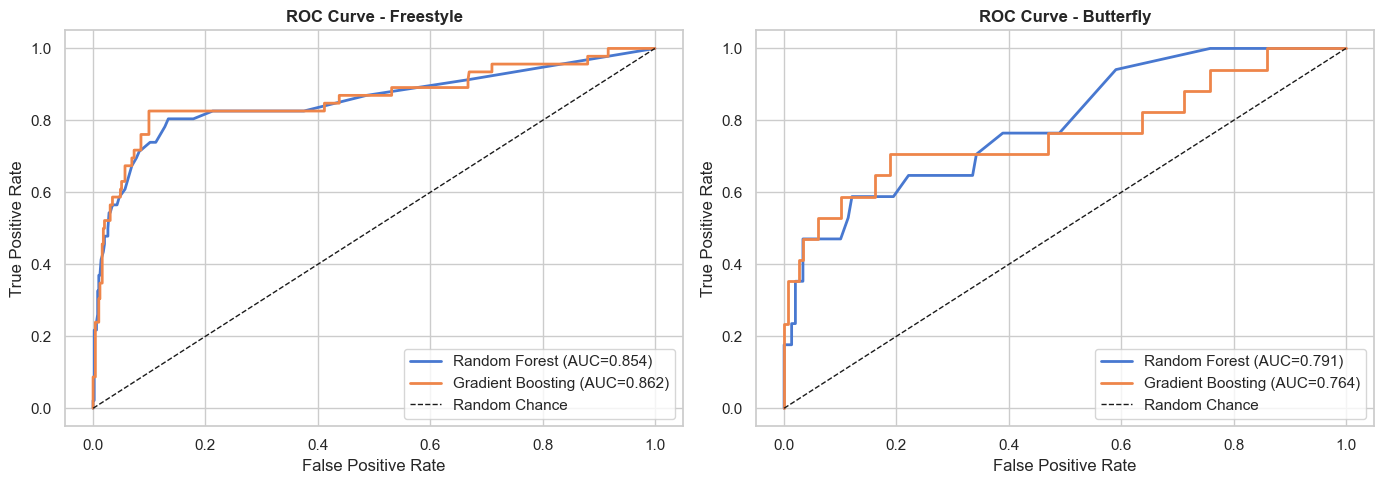

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, (models_dict, X_test, y_test, title) in zip(axes, [
    (freestyle_models, freestyle_X_test, freestyle_y_test, 'Freestyle'),
    (butterfly_models, butterfly_X_test, butterfly_y_test, 'Butterfly')
]):
    for name, m in models_dict.items():
        y_proba = m.predict_proba(X_test)[:, 1]
        fpr, tpr, _ = roc_curve(y_test, y_proba)
        auc = roc_auc_score(y_test, y_proba)
        ax.plot(fpr, tpr, label=f'{name} (AUC={auc:.3f})', lw=2)
    
    ax.plot([0, 1], [0, 1], 'k--', lw=1, label='Random Chance')
    ax.set_title(f'ROC Curve - {title}', fontsize=12, fontweight='bold')
    ax.set_xlabel('False Positive Rate')
    ax.set_ylabel('True Positive Rate')
    ax.legend(loc='lower right')

plt.tight_layout()
plt.show()

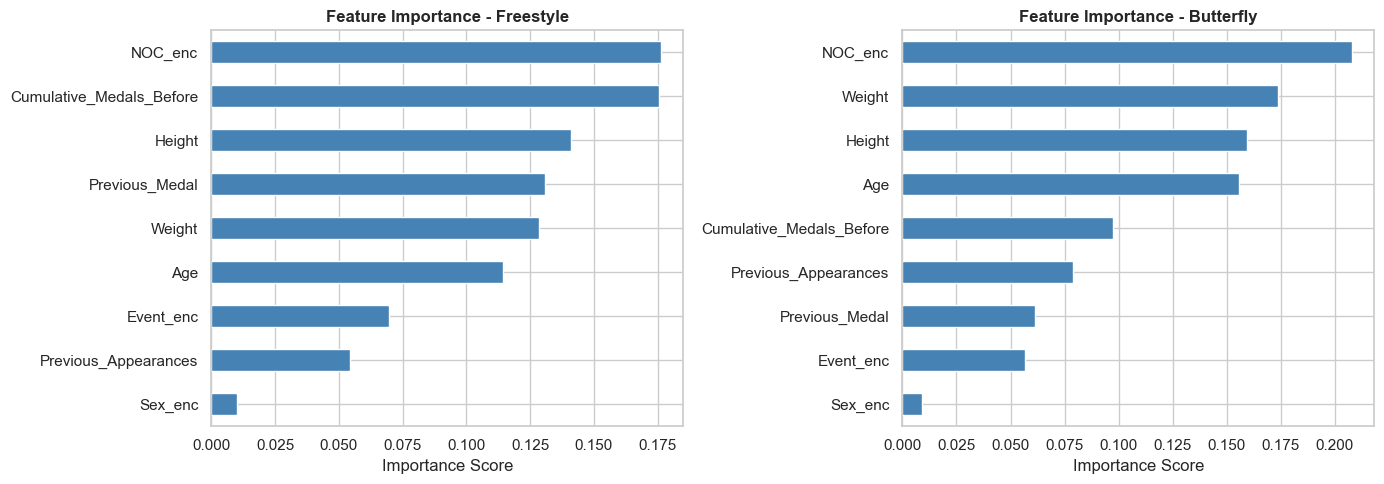

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

freestyle_rf = freestyle_models['Random Forest']
butterfly_rf = butterfly_models['Random Forest']

Features = [
    'Age', 'Height', 'Weight',
    'Sex_enc', 'Event_enc', 'NOC_enc',
    'Previous_Appearances',
    'Cumulative_Medals_Before',
    'Previous_Medal'
]

for ax, (m, title) in zip(axes, [
    (freestyle_rf, 'Freestyle'),
    (butterfly_rf, 'Butterfly')
]):
    importances = pd.Series(m.feature_importances_, index=Features)
    importances = importances.sort_values(ascending=True)
    importances.plot(kind='barh', ax=ax, color='steelblue', edgecolor='white')
    ax.set_title(f'Feature Importance - {title}', fontsize=12, fontweight='bold')
    ax.set_xlabel('Importance Score')

plt.tight_layout()
plt.show()

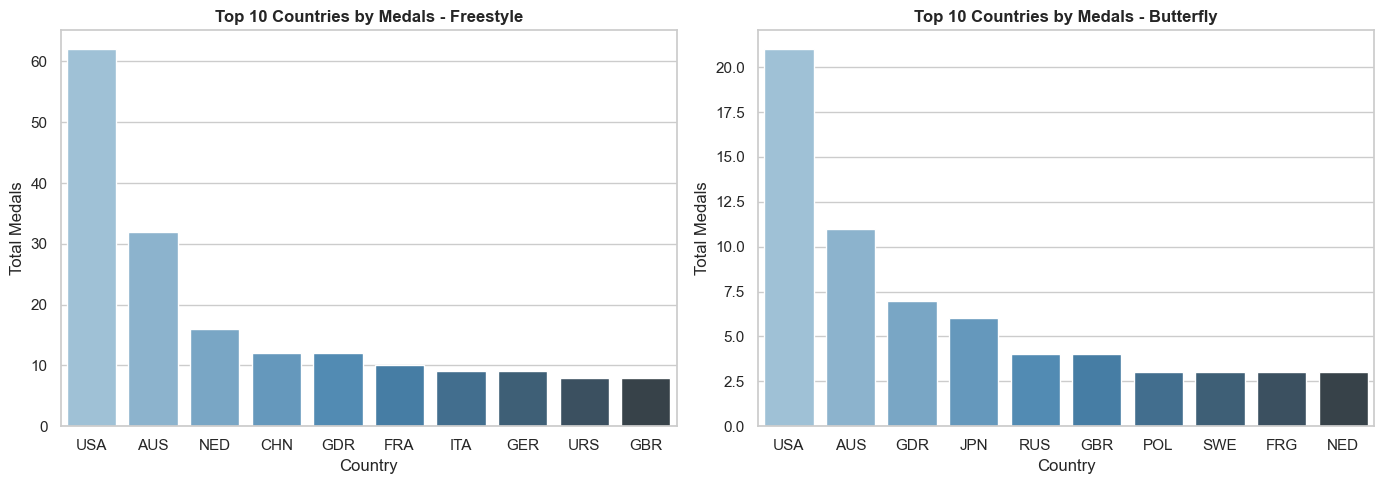

In [ ]:
#Medal distribution by country
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, (df, title) in zip(axes, [
    (freestyle_df, 'Freestyle'),
    (butterfly_df, 'Butterfly')
]):
    top_medals = (
        df[df['Medal_Won'] == 1]
        .groupby('NOC').size()
        .sort_values(ascending=False)
        .head(10)
        .reset_index()
    )
    top_medals.columns = ['NOC', 'Medal_Count']
    sns.barplot(data=top_medals, x='NOC', y='Medal_Count', 
                palette='Blues_d', ax=ax)
    ax.set_title(f'Top 10 Countries by Medals - {title}', 
                 fontsize=12, fontweight='bold')
    ax.set_xlabel('Country')
    ax.set_ylabel('Total Medals')

plt.tight_layout()
plt.show()

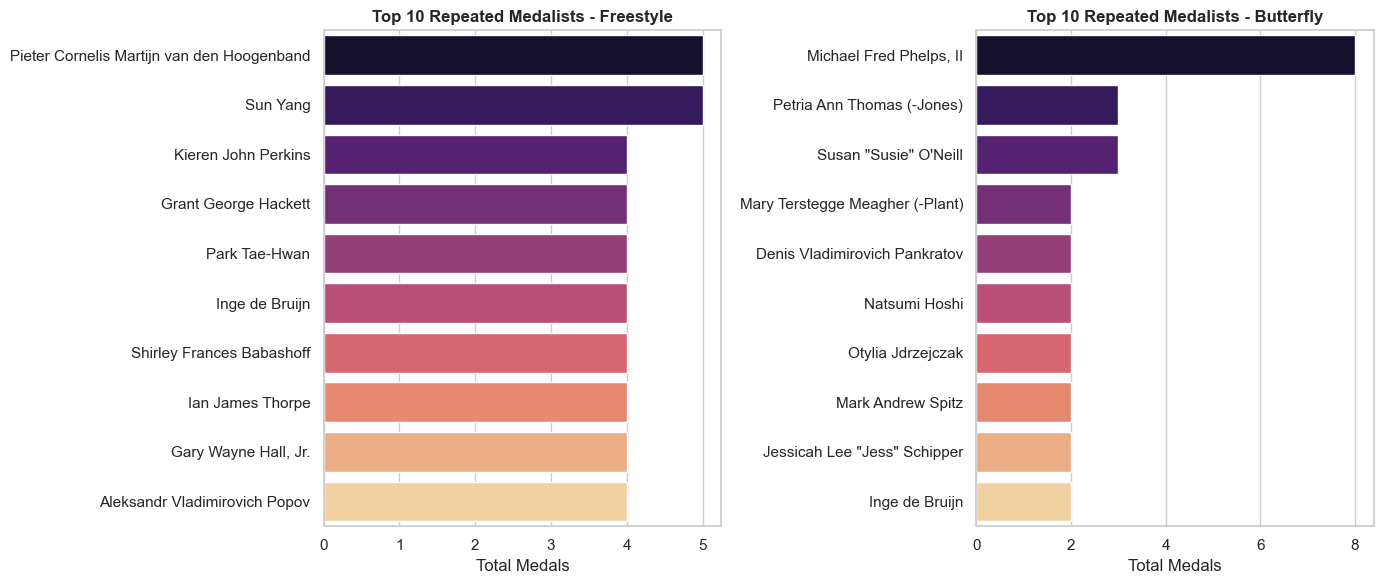

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, (df, title) in zip(axes, [
    (freestyle_df, 'Freestyle'),
    (butterfly_df, 'Butterfly')
]):
    repeat = (
        df[df['Medal_Won'] == 1]
        .groupby('Name').size()
        .sort_values(ascending=False)
        .head(10)
        .reset_index()
    )
    repeat.columns = ['Name', 'Total_Medals']
    sns.barplot(data=repeat, y='Name', x='Total_Medals',
                palette='magma', ax=ax)
    ax.set_title(f'Top 10 Repeated Medalists - {title}', 
                 fontsize=12, fontweight='bold')
    ax.set_xlabel('Total Medals')
    ax.set_ylabel('')

plt.tight_layout()
plt.show()

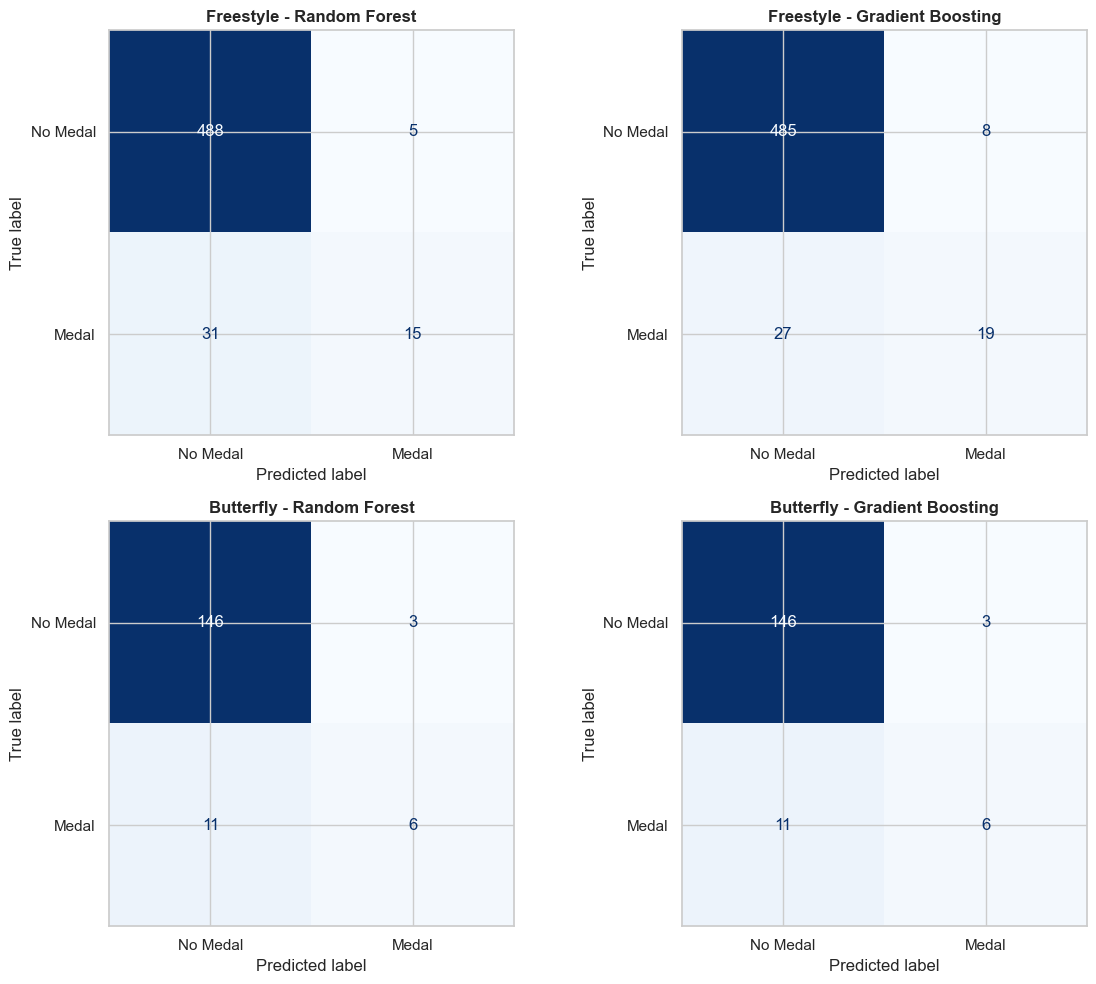

In [ ]:
#  Confusion matrices
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

for i, (models_dict, X_test, y_test, group) in enumerate([
    (freestyle_models, freestyle_X_test, freestyle_y_test, 'Freestyle'),
    (butterfly_models, butterfly_X_test, butterfly_y_test, 'Butterfly')
]):
    for j, (name, m) in enumerate(models_dict.items()):
        y_pred = m.predict(X_test)
        cm = confusion_matrix(y_test, y_pred)
        disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                                       display_labels=['No Medal', 'Medal'])
        disp.plot(ax=axes[i][j], colorbar=False, cmap='Blues')
        axes[i][j].set_title(f'{group} - {name}', fontweight='bold')

plt.tight_layout()
plt.show()